In [1]:
%pip install pydeseq2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 113.9 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scispacy 0.6.2 requires numpy<2.0, but you have numpy 2.5.3 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install archs4py

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 21.4 MB/s  0:00:00 18.5 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 113.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 161.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 153.2 MB/s  0:00:00
  Created wheel for archs4py: filename=archs4py-1.0.4-py3-none-any.whl size=18502 sha256=6288b611306e633daf1ba71e8d5d44c9d3d9f62f9c4ba04670255caa4e94ddb1
  Stored in directory: /home/vik/.cache/pip/wheels/86/61/c7/0e4580ce6350339f0ac5915c8e1b3c2b9481f98142612be521
  C

In [4]:
%wget https://s3.k8s.maayanlab.cloud/archs4/files/human_gene_v2.latest.h5

UsageError: Line magic function `%wget` not found.


In [1]:
#imports
from pathlib import Path
import pandas as pd
import archs4py as a4
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#load ground control and space flight from specified cohort (copy from cluster_metadata)

def get_counts_metadata(cohort_name,clist): #returns counts and metadata dataframes
    human_archs4_path = '/media/volume/H5-Files/archs4/human_gene_v2.latest.h5'
    mouse_archs4_path = '/home/vik/bridge-rna/archs4h5/mouse_gene_v2.5.h5'
    folder = Path.cwd().parent / "archs4data"/ "archs4hitscohort_alt_pre"
    full_name = folder / f"{cohort_name}_hits.csv"
    ch_df = pd.read_csv(full_name)
    
    #select GSM,spaceflight
    metadata = ch_df[['gsm','spaceflight']]
    metadata = metadata.groupby('gsm').filter(lambda x : len(x)<2) #drop samples that appear in ground and space
    metadata = metadata.set_index("gsm")
    metadata.index.name = None
    metadata = metadata[metadata['spaceflight'].isin(clist)]
    metadata = metadata.sort_index()
    

    #get counts
    gsms = metadata.index.tolist()
    #print(gsms)
    #gsm may be in human or mouse. but would they ever be mixed human and mouse?
    #for now just try mouse and if it fails then go human
    
    sample_counts = a4.data.samples(mouse_archs4_path,gsms)
    if sample_counts.empty:
        print("Human isn't downloaded yet")
        raise ValueError("Human isn't downloaded yet")
        sample_counts = a4.data.samples(human_archs4_path,gsms)
    sample_counts = sample_counts.groupby(sample_counts.index).agg(func='sum') #collapses all the dupes
    sample_counts = sample_counts.T
    sample_counts = sample_counts.sort_index()
    
    
    
    return sample_counts,metadata
        
    
    

In [124]:

cohort = 'OSD-714'
counts_df,metadata_df = get_counts_metadata(cohort,['Ground Control','Space Flight'])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 57.37it/s]


In [125]:
metadata_df["spaceflight"] = pd.Categorical(
    metadata_df["spaceflight"],
    categories=["Ground Control", "Space Flight"],
    ordered=True
)

In [126]:
counts_df

,0610005C13Rik,0610006L08Rik,0610009B22Rik,0610009E02Rik,0610009L18Rik,0610010K14Rik,0610012D04Rik,0610012G03Rik,0610025J13Rik,0610030E20Rik,...,n-R5s58,n-R5s60,n-R5s64,n-R5s65,n-R5s7,n-R5s71,n-R5s86,n-R5s88,n-R5s92,n-R5s93
GSM2732898,46,0,321,31,215,229,2,1172,7,460,...,0,0,0,0,0,0,0,0,0,0
GSM3473946,16,1,351,15,195,184,5,1140,6,306,...,0,0,0,0,0,0,0,0,0,0
GSM4817525,2,0,34,8,37,46,2,256,5,170,...,0,0,0,0,0,0,0,0,0,0
GSM4817531,8,0,24,12,37,82,1,269,3,190,...,0,0,0,0,0,0,0,0,0,0
GSM4952366,56,0,603,63,565,852,1,1874,15,1729,...,0,0,0,0,0,0,0,0,0,0
GSM4952410,47,2,677,81,584,1023,6,1978,11,1601,...,0,0,0,0,0,0,0,0,0,0
GSM5388354,9,0,123,51,32,137,1,128,0,226,...,1,0,0,0,0,0,0,0,0,0
GSM5667351,18,0,260,17,167,396,12,1026,14,607,...,0,0,0,0,0,0,0,0,0,0
GSM5686451,38,0,361,45,137,330,5,657,14,888,...,0,0,0,0,0,0,0,0,0,0
GSM6426650,12,1,257,22,66,36,5,520,1,427,...,0,0,0,0,0,0,0,0,0,0


In [127]:
counts_df.columns[counts_df.columns.duplicated()]

Index([], dtype='str')

In [128]:
metadata_df.index.tolist()

['GSM2732898',
 'GSM3473946',
 'GSM4817525',
 'GSM4817531',
 'GSM4952366',
 'GSM4952410',
 'GSM5388354',
 'GSM5667351',
 'GSM5686451',
 'GSM6426650',
 'GSM6426651',
 'GSM7412607',
 'GSM7501834',
 'GSM7501835']

In [129]:
metadata_df

,spaceflight
GSM2732898,Ground Control
GSM3473946,Space Flight
GSM4817525,Space Flight
GSM4817531,Space Flight
GSM4952366,Space Flight
GSM4952410,Space Flight
GSM5388354,Space Flight
GSM5667351,Space Flight
GSM5686451,Space Flight
GSM6426650,Space Flight


In [130]:
#load them into the deseq format
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata_df,
    design="spaceflight",  # compare samples based on the "condition"
    # column ("B" vs "A")
    refit_cooks=True,
    inference=inference,
)

In [131]:
'''
Size factors: Scaling factors, for normalization
Genewise dispersions: variability in each gene's counts accross replicates
Replicate: samples with the same condition (i.e Ground)
Trend Coeff: Dispersion-mean trend (smooth curve). The coeffs are the coeffs for the parametric model
*for DE Analysis, it is not necessary to use gene lengths to estimate the scaling factors (it is even not recommended) (i.e typical normalization methods)
Deseq uses a different normalization method
MAP dispersion: applies shrinkage; uses Bayes empirical shrinkage
LFC: Log fold change

'''

"\nSize factors: Scaling factors, for normalization\nGenewise dispersions: variability in each gene's counts accross replicates\nReplicate: samples with the same condition (i.e Ground)\nTrend Coeff: Dispersion-mean trend (smooth curve). The coeffs are the coeffs for the parametric model\n*for DE Analysis, it is not necessary to use gene lengths to estimate the scaling factors (it is even not recommended) (i.e typical normalization methods)\nDeseq uses a different normalization method\nMAP dispersion: applies shrinkage; uses Bayes empirical shrinkage\nLFC: Log fold change\n\n"

In [132]:
dds.fit_size_factors() 
dds.obs["size_factors"]

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.



GSM2732898    1.408231
GSM3473946    1.022835
GSM4817525    0.409988
GSM4817531    0.377219
GSM4952366    2.601738
GSM4952410    2.766567
GSM5388354    0.397839
GSM5667351    1.291682
GSM5686451    1.301604
GSM6426650    1.138613
GSM6426651    0.645081
GSM7412607    1.821058
GSM7501834    0.962601
GSM7501835    0.870143
Name: size_factors, dtype: float64

In [133]:
dds.fit_genewise_dispersions()
dds.var["genewise_dispersions"]

Fitting dispersions...
... done in 48.35 seconds.



0610005C13Rik    9.261879e-02
0610006L08Rik    1.000000e-08
0610009B22Rik    3.788667e-01
0610009E02Rik    4.218391e-01
0610009L18Rik    1.577915e-01
                     ...     
n-R5s71                   NaN
n-R5s86                   NaN
n-R5s88                   NaN
n-R5s92                   NaN
n-R5s93                   NaN
Name: genewise_dispersions, Length: 53454, dtype: float64

In [134]:
dds.fit_dispersion_trend()
dds.uns["trend_coeffs"]
dds.var["fitted_dispersions"]

Fitting dispersion trend curve...
... done in 1.63 seconds.



0610005C13Rik     0.675873
0610006L08Rik    31.398056
0610009B22Rik     0.388538
0610009E02Rik     0.547236
0610009L18Rik     0.400206
                   ...    
n-R5s71                NaN
n-R5s86                NaN
n-R5s88                NaN
n-R5s92                NaN
n-R5s93                NaN
Name: fitted_dispersions, Length: 53454, dtype: float64

In [135]:
dds.fit_dispersion_prior()
print(
    f"logres_prior={dds.uns['_squared_logres']}, sigma_prior={dds.uns['prior_disp_var']}"
)

logres_prior=0.9177349187333007, sigma_prior=0.7364119629961854


In [136]:
dds.fit_MAP_dispersions()
dds.var["MAP_dispersions"]
dds.var["dispersions"]

Fitting MAP dispersions...
... done in 53.13 seconds.



0610005C13Rik     0.188826
0610006L08Rik    14.000000
0610009B22Rik     0.380525
0610009E02Rik     0.443880
0610009L18Rik     0.190806
                   ...    
n-R5s71                NaN
n-R5s86                NaN
n-R5s88                NaN
n-R5s92                NaN
n-R5s93                NaN
Name: dispersions, Length: 53454, dtype: float64

In [137]:
dds.fit_LFC()
dds.varm["LFC"]

Fitting LFCs...
... done in 47.33 seconds.



,Intercept,spaceflight[T.Space Flight]
0610005C13Rik,3.486306,-0.638042
0610006L08Rik,-2.035434,0.932616
0610009B22Rik,5.429105,-0.133615
0610009E02Rik,3.091652,0.325571
0610009L18Rik,5.028303,-0.067733
...,...,...
n-R5s71,NaN,NaN
n-R5s86,NaN,NaN
n-R5s88,NaN,NaN
n-R5s92,NaN,NaN


In [138]:
dds.calculate_cooks()
if dds.refit_cooks:
    # Replace outlier counts
    dds.refit()

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 25860 outlier genes.

Fitting dispersions...
... done in 30.78 seconds.

Fitting MAP dispersions...
... done in 33.96 seconds.

Fitting LFCs...
... done in 30.24 seconds.



In [139]:
ds = DeseqStats(
    dds,
    contrast=["spaceflight", "Space Flight", "Ground Control"],
    alpha=0.05,
    cooks_filter=True,
    independent_filter=True,
)

In [140]:
ds.run_wald_test()
ds.p_values

Running Wald tests...
... done in 15.66 seconds.



0610005C13Rik    0.183437
0610006L08Rik    0.837878
0610009B22Rik    0.835373
0610009E02Rik    0.649523
0610009L18Rik    0.882714
                   ...   
n-R5s71               NaN
n-R5s86               NaN
n-R5s88               NaN
n-R5s92               NaN
n-R5s93               NaN
Length: 53454, dtype: float64

In [141]:
ds.summary()

Log2 fold change & Wald test p-value: spaceflight Space Flight vs Ground Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
0610005C13Rik   18.107455       -0.920500  0.691977 -1.330246  0.183437   
0610006L08Rik    0.184204        1.345480  6.575880  0.204608  0.837878   
0610009B22Rik  201.252794       -0.192766  0.927580 -0.207816  0.835373   
0610009E02Rik   30.556469        0.469700  1.033614  0.454425  0.649523   
0610009L18Rik  142.659503       -0.097719  0.662366 -0.147530  0.882714   
...                   ...             ...       ...       ...       ...   
n-R5s71          0.000000             NaN       NaN       NaN       NaN   
n-R5s86          0.000000             NaN       NaN       NaN       NaN   
n-R5s88          0.000000             NaN       NaN       NaN       NaN   
n-R5s92          0.000000             NaN       NaN       NaN       NaN   
n-R5s93          0.000000             NaN       NaN       NaN       NaN   

                  

In [142]:
#visualization 
df = ds.results_df

In [143]:
df.columns

Index(['baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj'], dtype='str')

In [144]:
#save summary to folder

df.to_csv(f"deseq_summaries_alt/{cohort}",index=True)

In [171]:
#test load
read_cohort = 'OSD-513'
loaded_df = pd.read_csv(f'deseq_summaries_alt/{read_cohort}',index_col=0)

In [172]:
loaded_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0610005C13Rik,1503.721302,0.335117,0.190519,1.758970,0.078583,0.180480
0610006L08Rik,281.900705,0.079104,0.228888,0.345602,0.729642,0.832614
0610009B22Rik,421.103123,0.547685,0.179140,3.057303,0.002233,0.012225
0610009E02Rik,51.373943,0.313116,0.229325,1.365382,0.172133,0.317099
0610009L18Rik,32.493222,1.151744,0.287775,4.002239,0.000063,0.000744
...,...,...,...,...,...,...
n-R5s71,0.000000,NaN,NaN,NaN,NaN,NaN
n-R5s86,0.000000,NaN,NaN,NaN,NaN,NaN
n-R5s88,0.000000,NaN,NaN,NaN,NaN,NaN
n-R5s92,0.000000,NaN,NaN,NaN,NaN,NaN


In [173]:
#pydeseq2 imports are not working, this is a direct copy paste of their function
from typing import Literal
def make_MA_plot(
    results_df: pd.DataFrame,
    padj_thresh: float = 0.05,
    log: bool = True,
    save_path: str | None = None,
    lfc_null: float = 0,
    alt_hypothesis: Literal["greaterAbs", "lessAbs", "greater", "less"] | None = None,
    **kwargs,
) -> None:
    """
    Create an log ratio (M)-average (A) plot using matplotlib.

    Useful for looking at log fold-change versus mean expression between two groups/samples/etc.
    Uses matplotlib to emulate the ``make_MA()`` function in DESeq2 in R.

    Parameters
    ----------
    results_df
        Resultant dataframe after running DeseqStats() and .summary().
    padj_thresh
        P-value threshold to subset scatterplot colors on.
    log
        Whether or not to log scale features and targets axes (``default=True``).
    save_path
        The path where to save the plot.
        If left None, the plot won't be saved (``default=None``).
    lfc_null
        The (log2) log fold change under the null hypothesis. (default: ``0``).
    alt_hypothesis
        The alternative hypothesis for computing wald p-values. (default: ``None``).
    **kwargs
        Matplotlib keyword arguments for the scatter plot.
    """
    colors = results_df["padj"].apply(lambda x: "darkred" if x < padj_thresh else "gray")

    fig, ax = plt.subplots(dpi=600)

    # Set default alpha and s parameters, if not already specified
    kwargs.setdefault("alpha", 0.5)
    kwargs.setdefault("s", 0.2)

    plt.scatter(
        x=results_df["baseMean"],
        y=results_df["log2FoldChange"],
        c=colors,
        **kwargs,
    )

    ax.set_adjustable("datalim")

    if log is True:
        plt.xscale("log")

    plt.xlabel("mean of normalized counts")
    plt.ylabel("log2 fold change")
    plt.title(f"MA Plot: {read_cohort} Ground Control ARCHS4 Hits vs Spaceflight ARCHS4 Hits")

    plt.axhline(lfc_null, color="red", alpha=0.5, linestyle="--", zorder=3)
    if alt_hypothesis and alt_hypothesis in ["greaterAbs", "lessAbs"]:
        plt.axhline(-lfc_null, color="red", alpha=0.5, linestyle="--", zorder=3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

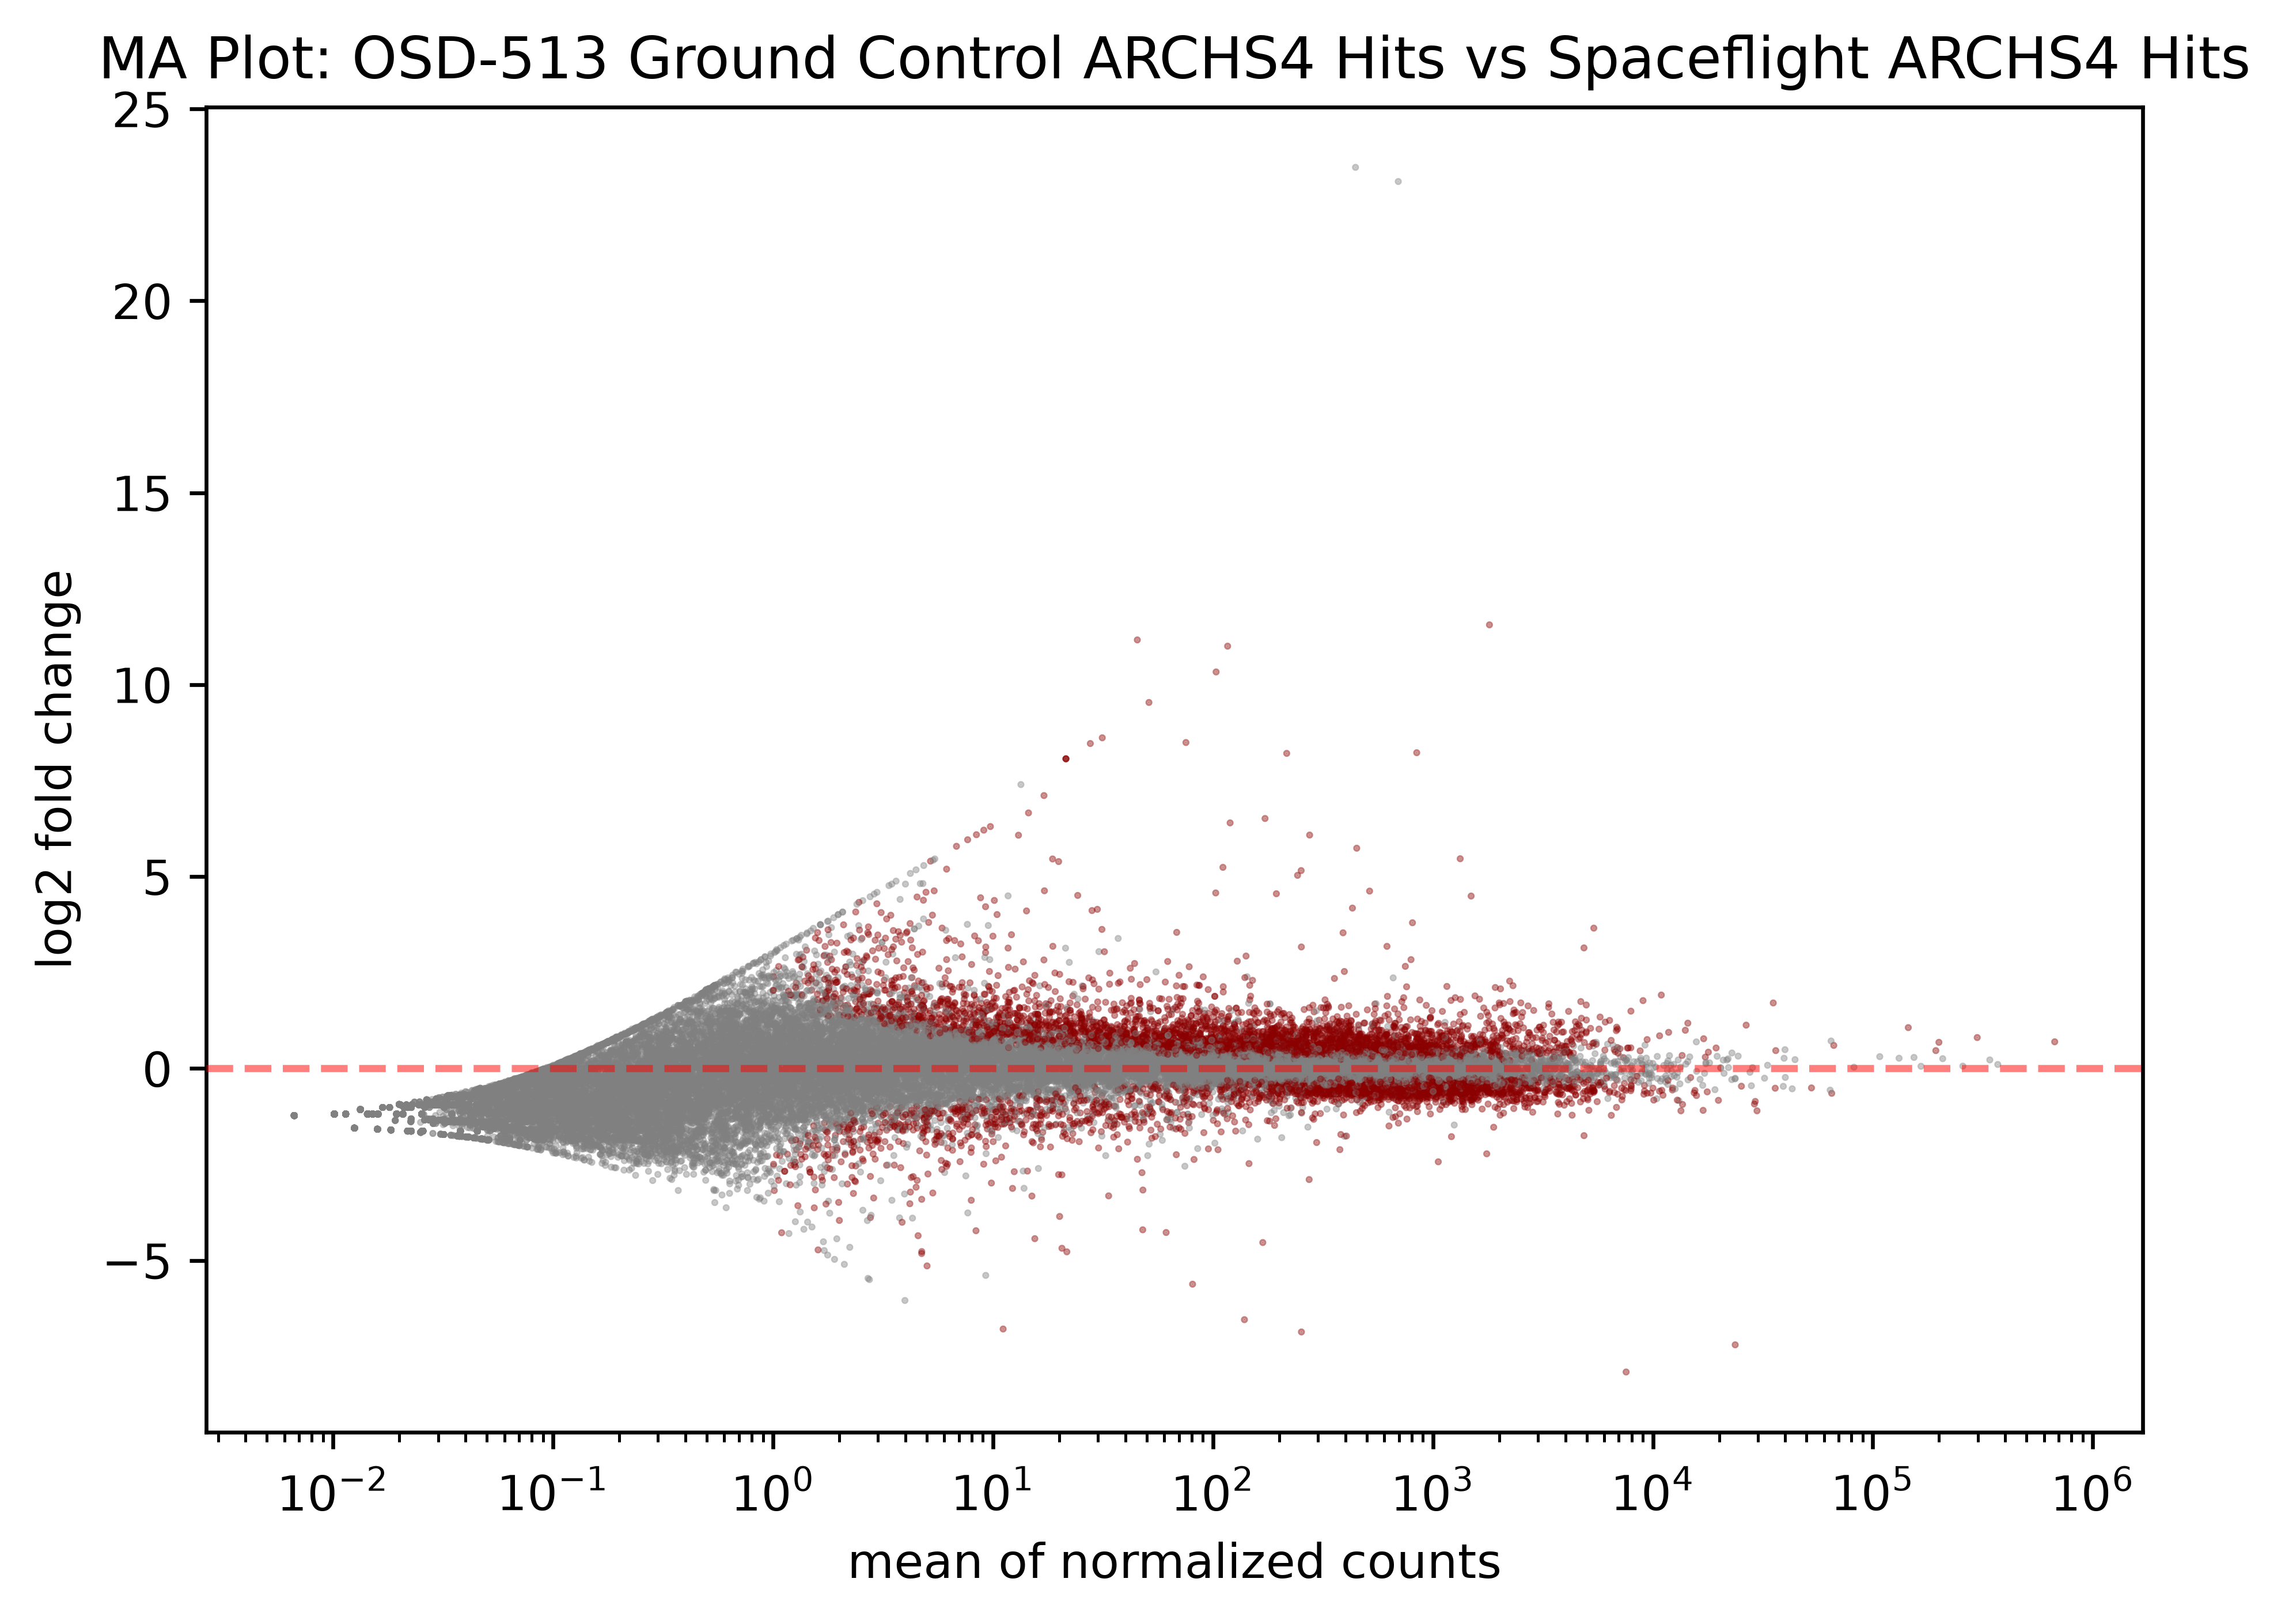

In [174]:
make_MA_plot(loaded_df)


In [175]:
%pip install gseapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.9/689.9 kB 22.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [177]:
loaded_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0610005C13Rik,1503.721302,0.335117,0.190519,1.758970,0.078583,0.180480
0610006L08Rik,281.900705,0.079104,0.228888,0.345602,0.729642,0.832614
0610009B22Rik,421.103123,0.547685,0.179140,3.057303,0.002233,0.012225
0610009E02Rik,51.373943,0.313116,0.229325,1.365382,0.172133,0.317099
0610009L18Rik,32.493222,1.151744,0.287775,4.002239,0.000063,0.000744
...,...,...,...,...,...,...
n-R5s71,0.000000,NaN,NaN,NaN,NaN,NaN
n-R5s86,0.000000,NaN,NaN,NaN,NaN,NaN
n-R5s88,0.000000,NaN,NaN,NaN,NaN,NaN
n-R5s92,0.000000,NaN,NaN,NaN,NaN,NaN


In [176]:
##gsea?###
import gseapy as gp
from gseapy.plot import gseaplot
ranking = loaded_df[['Symbol', 'stat']].dropna().sort_values('stat', ascending = False)


KeyError: "['Symbol'] not in index"